<a href="https://colab.research.google.com/github/mansorabi324/7-Abiyyu-Derryl/blob/main/Abiyyu_EDA_Week%202.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd

In [4]:
df =pd.read_csv('train.csv')

## Memahami dataset

In [5]:
df.shape

(54808, 13)

In [6]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


In [8]:
df.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'awards_won?', 'avg_training_score',
       'is_promoted'],
      dtype='object')

## Menegecek misisng value

In [9]:
df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [10]:
from sklearn.impute import SimpleImputer

In [11]:
# # missing value pada categoric
# imputer = SimpleImputer(strategy='most_frequent')
# df['education'] = imputer.fit_transform(df[['education']])

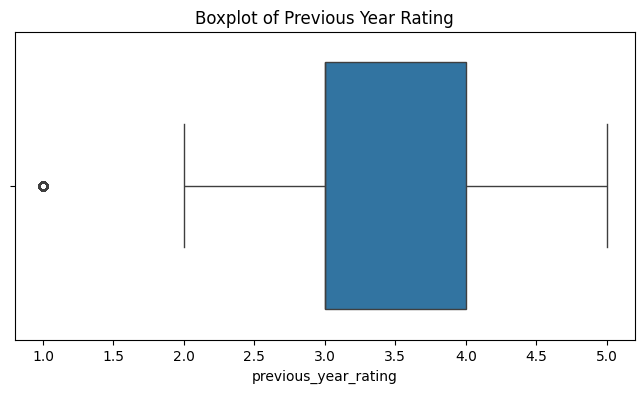

In [12]:
# missing value pada numeric
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['previous_year_rating'])
plt.title('Boxplot of Previous Year Rating')
plt.show()

In [13]:
# imputer = SimpleImputer(strategy='median')
# df['previous_year_rating'] = imputer.fit_transform(df[['previous_year_rating']])

In [14]:
df.isnull().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


## Statistik deskriptif

In [15]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,99.000000,1.000000


## analisis distribusi data (numeric)

In [16]:
pd.set_option('display.max_rows', None)
df['avg_training_score'].value_counts()

,count
avg_training_score,
50,2716
49,2681
48,2437
51,2347
60,2155
59,2064
58,1898
61,1879
52,1856


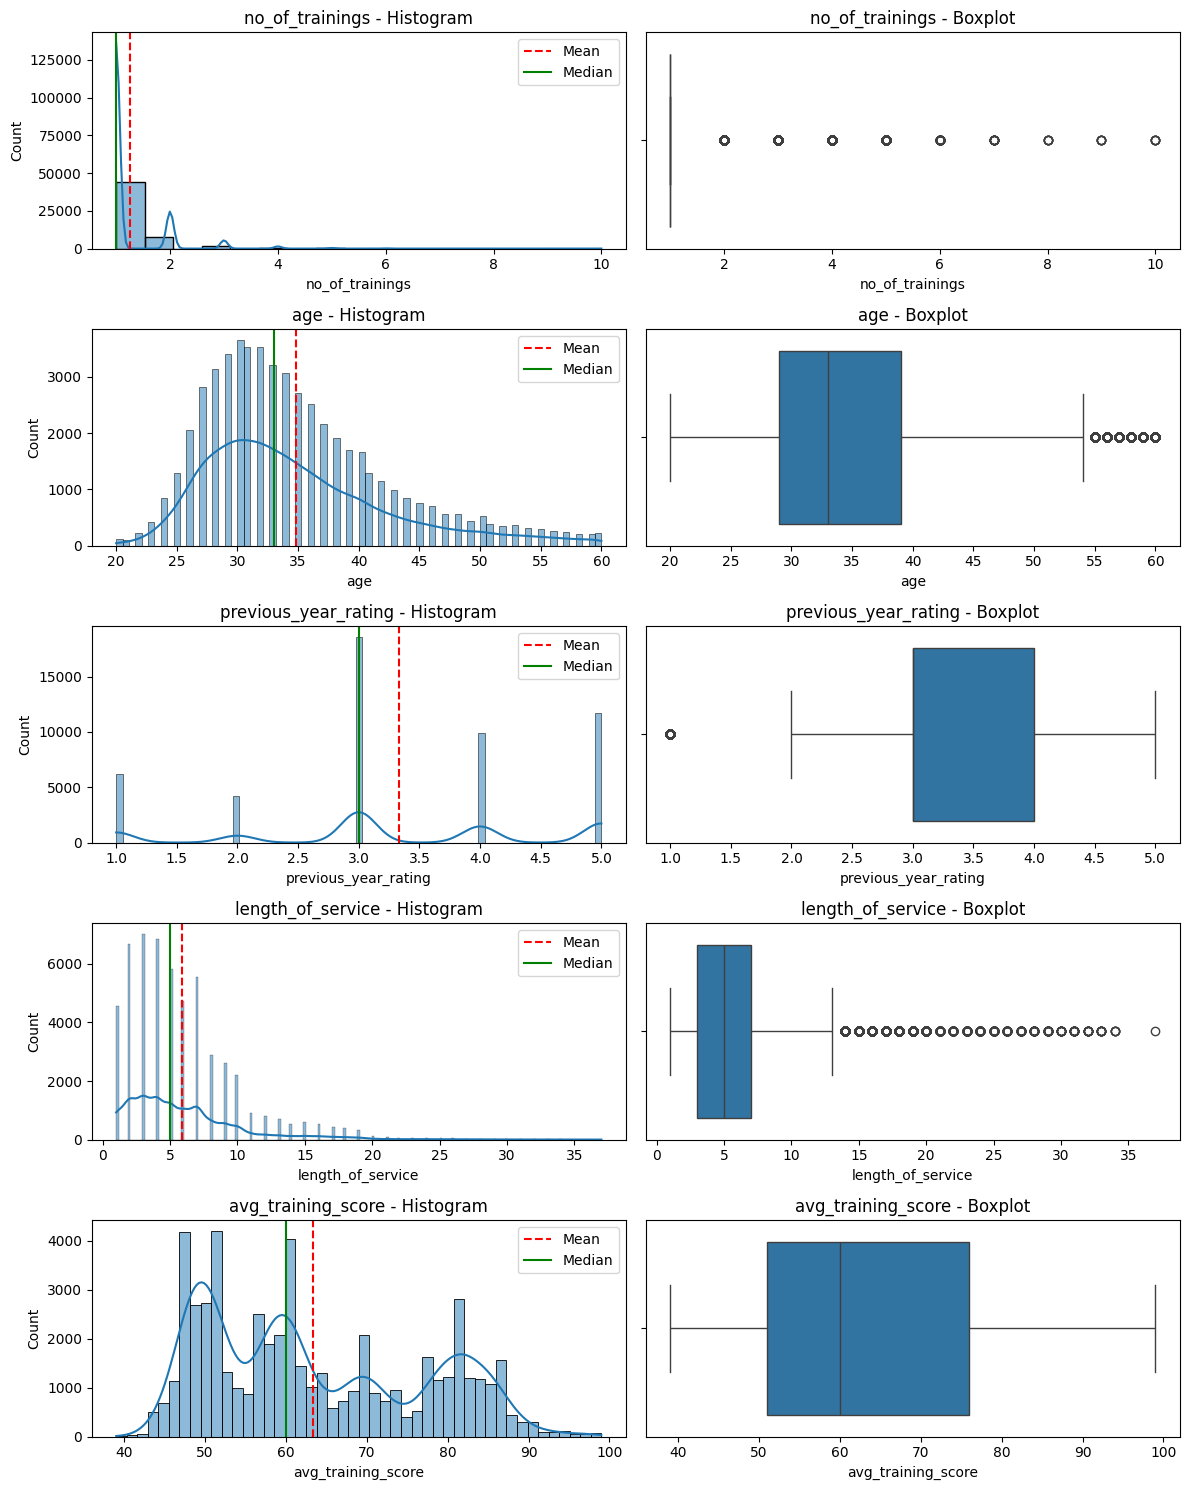

In [17]:
numerical_cols = ['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'avg_training_score']

fig, axes = plt.subplots(len(numerical_cols), 2, figsize=(12, len(numerical_cols)*3))

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} - Histogram')
    axes[i, 0].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i, 0].axvline(df[col].median(), color='green', linestyle='-', label='Median')
    axes[i, 0].legend()

    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} - Boxplot')

plt.tight_layout()
plt.show()

In [18]:
df.groupby('no_of_trainings')['avg_training_score'].mean()

,avg_training_score
no_of_trainings,
1,62.984835
2,65.344059
3,64.774212
4,64.211538
5,60.078125
6,58.386364
7,59.666667
8,65.600000
9,67.800000


In [19]:
df.groupby('is_promoted')['age'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
is_promoted,,,,
0,34.844037,33.0,20,60
1,34.372965,33.0,20,60


In [20]:
df.groupby('is_promoted')['previous_year_rating'].agg(['mean', 'median'])

,mean,median
is_promoted,,
0,3.267911,3.0
1,3.986140,4.0


In [21]:
df.groupby('is_promoted')['length_of_service'].agg(['mean', 'median', 'min', 'max'])

,mean,median,min,max
is_promoted,,,,
0,5.879398,5.0,1,37
1,5.716367,5.0,1,34
